# Viewing Angle Analysis


## 1. Environment Setup


In [2]:
!python -m pip install -U ultralytics


In [3]:
from ultralytics import YOLO
import torch
import os
from collections import Counter

In [4]:
device = "cpu"

print("Running on CPU")
print("CUDA available:", torch.cuda.is_available())

Running on CPU
CUDA available: False


In [5]:
DATASET_PATH = "YOLO_COCO_view_angle"
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    print("Images:", os.listdir(f"{DATASET_PATH}/images/{split}")[:3])
    print("Labels:", os.listdir(f"{DATASET_PATH}/labels/{split}")[:3])


TRAIN
Images: ['00c5540b-S3_front.jpg', '01427304-IMG_20251113_163504.jpg', '01e24ee9-IMG_20251106_145403.jpg']
Labels: ['00c5540b-S3_front.txt', '01427304-IMG_20251113_163504.txt', '01e24ee9-IMG_20251106_145403.txt']

VAL
Images: ['00e11d0f-IMG_20251112_161550.jpg', '01f292e8-IMG_20251202_111915.jpg', '027b4109-IMG_20251106_154019.jpg']
Labels: ['00e11d0f-IMG_20251112_161550.txt', '01f292e8-IMG_20251202_111915.txt', '027b4109-IMG_20251106_154019.txt']

TEST
Images: ['00abf266-WhatsApp_Image_2026-01-03_at_18.45.21_1.jpeg', '00e70ac4-IMG_20251111_140913.jpg', '0818c28d-20251108_012029.jpg']
Labels: ['00abf266-WhatsApp_Image_2026-01-03_at_18.45.21_1.txt', '00e70ac4-IMG_20251111_140913.txt', '0818c28d-20251108_012029.txt']


In [16]:
from ultralytics import YOLO
import os

# Absolute, explicit save directory (prevents YOLO from guessing)
SAVE_DIR = os.path.abspath("runs/viewing_angle")

model = YOLO("yolov8n.pt")

model.train(
    data="YOLO_COCO_view_angle/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device="cpu",
    project=SAVE_DIR,
    name="yolov8_view_angle"
)


Ultralytics 8.4.7  Python-3.10.19 torch-2.4.1 CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=YOLO_COCO_view_angle/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_view_angle, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002B69B1BD7B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [17]:
model.val(
    data="YOLO_COCO_view_angle/data.yaml",
    split="val",
    device="cpu"
)

Ultralytics 8.4.7  Python-3.10.19 torch-2.4.1 CPU (AMD Ryzen 7 5700U with Radeon Graphics)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 1054.7149.3 MB/s, size: 2069.3 KB)
val: Scanning C:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\labels\val.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.5s/it 17.4s2.9ss
                   all        111        174      0.844      0.681      0.768      0.609
                  Back         45         51      0.802      0.717      0.824      0.669
                 Front         56         71      0.819      0.732      0.737      0.581
                  Side         43         52      0.911      0.594      0.743      0.578
Speed: 1.3ms preprocess, 61.3ms inference, 0.0ms loss, 5.5ms post

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002B6A24E2380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [18]:
model.val(
    data="YOLO_COCO_view_angle/data.yaml",
    split="test",
    device="cpu"
)

Ultralytics 8.4.7  Python-3.10.19 torch-2.4.1 CPU (AMD Ryzen 7 5700U with Radeon Graphics)
val: Fast image access  (ping: 0.50.2 ms, read: 563.3278.2 MB/s, size: 2127.7 KB)
val: Scanning C:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\labels\test.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5s/it 19.7s3.0ss
                   all        119        168       0.75      0.678      0.703      0.586
                  Back         48         51      0.749      0.821      0.789      0.689
                 Front         46         57       0.77      0.762       0.84      0.726
                  Side         50         60       0.73       0.45       0.48      0.343
Speed: 1.2ms preprocess, 63.3ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to C:\Users\joach\runs\detect\val12


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002B68BE40280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [19]:
results = model.predict(
    source="YOLO_COCO_view_angle/images/test",
    conf=0.25,
    device="cpu",
    save=True
)


image 1/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\00abf266-WhatsApp_Image_2026-01-03_at_18.45.21_1.jpeg: 640x480 1 Side, 93.8ms
image 2/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\00e70ac4-IMG_20251111_140913.jpg: 640x480 (no detections), 76.2ms
image 3/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0818c28d-20251108_012029.jpg: 640x480 1 Front, 1 Side, 74.2ms
image 4/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0b62eb5a-IMG_20251111_145534.jpg: 640x480 1 Side, 82.9ms
image 5/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0f6c89bd-IMG_20251111_155624.jpg: 640x480 1 Front, 81.3ms
image 6/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images

In [20]:
angle_map = {0: "front", 1: "side", 2: "back"}
counter = Counter()

for r in results:
    if r.boxes.cls is not None:
        for cls in r.boxes.cls.tolist():
            counter[angle_map[int(cls)]] += 1

print("Detected Viewing Angles:")
for angle, count in counter.items():
    print(f"{angle}: {count}")


Detected Viewing Angles:
back: 41
side: 61
front: 58


In [34]:
import os

# Project root = folder where this notebook lives
PROJECT_ROOT = os.path.abspath(os.getcwd())

DATASET_DIR = os.path.join(PROJECT_ROOT, "YOLO_COCO_view_angle")
RUNS_DIR = os.path.join(PROJECT_ROOT, "runs", "viewing_angle")
MODEL_PATH = os.path.join(RUNS_DIR, "yolov8_view_angle", "weights", "best.pt")

TEST_PRED_DIR = os.path.join(RUNS_DIR, "yolov8_view_angle", "test_predictions")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("TEST_PRED_DIR:", TEST_PRED_DIR)


PROJECT_ROOT: c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment
DATASET_DIR: c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle
MODEL_PATH: c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\runs\viewing_angle\yolov8_view_angle\weights\best.pt
TEST_PRED_DIR: c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\runs\viewing_angle\yolov8_view_angle\test_predictions


In [35]:
from ultralytics import YOLO

os.makedirs(TEST_PRED_DIR, exist_ok=True)

model = YOLO(MODEL_PATH)

model.predict(
    source=os.path.join(DATASET_DIR, "images", "test"),
    conf=0.25,
    device="cpu",
    save=True,
    project=TEST_PRED_DIR,
    name=".",          # IMPORTANT: prevents nested folders
)



image 1/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\00abf266-WhatsApp_Image_2026-01-03_at_18.45.21_1.jpeg: 640x480 1 Side, 157.9ms
image 2/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\00e70ac4-IMG_20251111_140913.jpg: 640x480 (no detections), 186.7ms
image 3/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0818c28d-20251108_012029.jpg: 640x480 1 Front, 1 Side, 219.2ms
image 4/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0b62eb5a-IMG_20251111_145534.jpg: 640x480 1 Side, 109.2ms
image 5/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\images\test\0f6c89bd-IMG_20251111_155624.jpg: 640x480 1 Front, 111.1ms
image 6/119 c:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\i

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Back', 1: 'Front', 2: 'Side'}
 obb: None
 orig_img: array([[[153, 121,  80],
         [153, 121,  80],
         [154, 122,  81],
         ...,
         [133,  81,  44],
         [133,  81,  44],
         [133,  81,  44]],
 
        [[153, 121,  80],
         [154, 122,  81],
         [154, 122,  81],
         ...,
         [133,  81,  44],
         [133,  81,  44],
         [133,  81,  44]],
 
        [[154, 122,  81],
         [154, 122,  81],
         [154, 122,  81],
         ...,
         [133,  81,  44],
         [133,  81,  44],
         [133,  81,  44]],
 
        ...,
 
        [[ 33,  39,  44],
         [ 32,  38,  43],
         [ 31,  37,  42],
         ...,
         [ 28,  37,  46],
         [ 28,  37,  46],
         [ 28,  37,  46]],
 
        [[ 33,  39,  44],
         [ 32,  38,  43],
         [ 32,  38,  43],
         ..

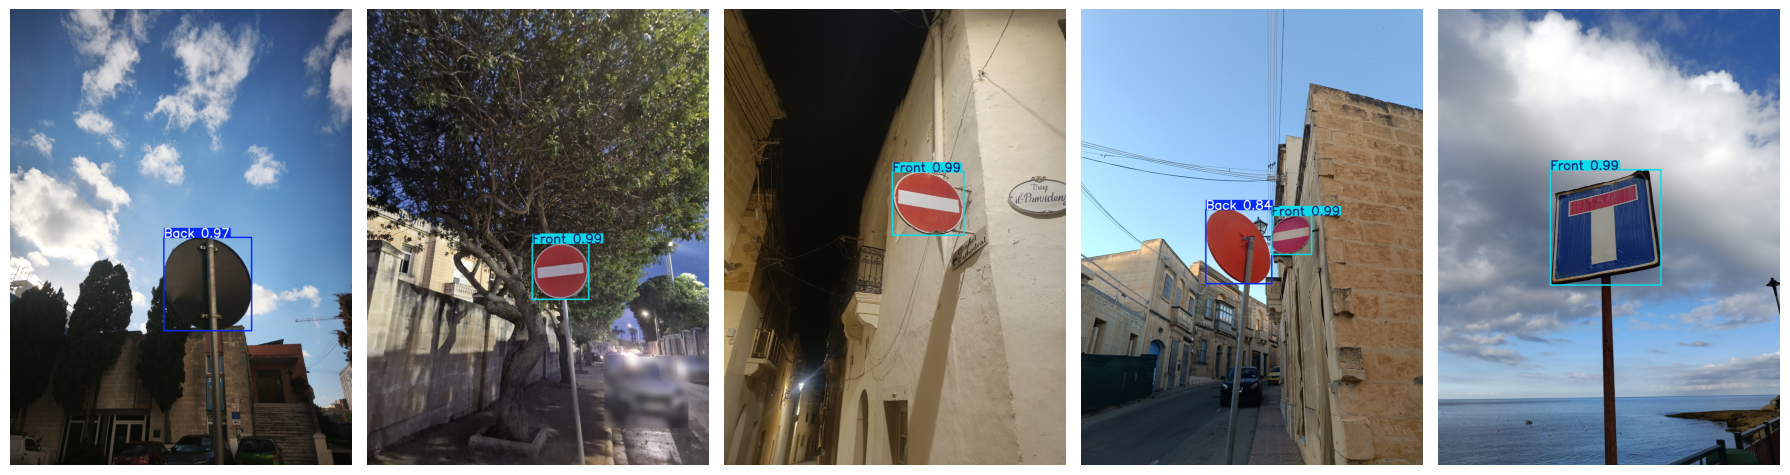

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Absolute path to prediction images
TEST_PRED_DIR = r"C:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\runs\viewing_angle\yolov8_view_angle\test_predictions"

# Collect images
all_images = [
    f for f in os.listdir(TEST_PRED_DIR)
    if f.lower().endswith((".jpg", ".png"))
]

# Randomly select 5 images
sampled_images = random.sample(all_images, min(5, len(all_images)))

plt.figure(figsize=(18, 6))

for i, img_name in enumerate(sampled_images):
    img_path = os.path.join(TEST_PRED_DIR, img_name)
    img = Image.open(img_path)

    plt.subplot(1, len(sampled_images), i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [37]:
metrics = model.val(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    split="test",
    device="cpu",
    project=RUNS_DIR,
    name="yolov8_view_angle"
)

print("mAP@50:", metrics.box.map50)
print("mAP@50–95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)


Ultralytics 8.4.7  Python-3.10.19 torch-2.4.1 CPU (AMD Ryzen 7 5700U with Radeon Graphics)
val: Fast image access  (ping: 0.50.1 ms, read: 384.564.6 MB/s, size: 1763.8 KB)
val: Scanning C:\Users\joach\OneDrive\Desktop\Uni\3rdYr\Sem1\CV-ARI3129\Assignment\YOLO_COCO_view_angle\labels\test.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 118.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.1s/it 33.1s4.7ss
                   all        119        168       0.75      0.678      0.703      0.586
                  Back         48         51      0.749      0.821      0.789      0.689
                 Front         46         57       0.77      0.762       0.84      0.726
                  Side         50         60       0.73       0.45       0.48      0.343
Speed: 2.0ms preprocess, 98.6ms inference, 0.0ms loss, 10.8ms postprocess per image
Results saved to C:\Users\joach\OneDrive\Desktop\Uni

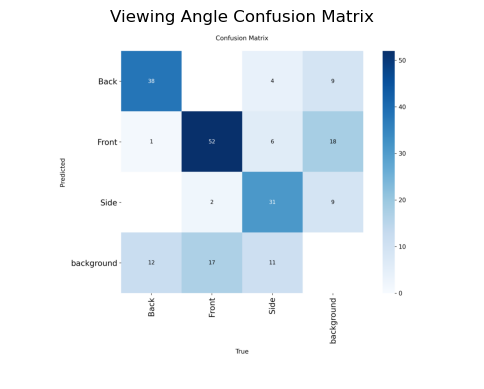

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import os

cm_path = os.path.join(
    "runs", "viewing_angle", "yolov8_view_angle", "confusion_matrix.png"
)

img = Image.open(cm_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Viewing Angle Confusion Matrix")
plt.show()
